## Importing Necessary Libraries

In [18]:
import pandas as pd
import os
import json
import random
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Activation
from keras.optimizers import Adam
from keras.regularizers import l2
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [19]:
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [ ]:
# for local run
BASE_DIR = os.path.dirname(os.getcwd()) 
filedr = os.path.join(BASE_DIR,'data/input')

# for kaggle
# BASE_DIR = "/kaggle/working"
# filedr = '/kaggle/input/car-color-dataset'

In [21]:
filedr

'/Users/jayant/Documents/projects/car-color-detection/data/input'

In [22]:
files = os.listdir(filedr)
files

['brown',
 'green',
 'blue',
 'silver',
 'grey',
 'pink',
 'red',
 'purple',
 'beige',
 'yellow',
 'white',
 'black',
 'tan',
 'orange']

In [23]:
# Reading and storing all images
images = []
labels = []
color_classes = os.listdir(filedr)
total_images = 0
failed_images = 0
for color_class in color_classes:
    class_success = 0
    class_fail = 0 
    color_path = os.path.join(filedr, color_class)
    print(f"Reading images from '{color_path}' ......", end=" ")
    for filename in os.listdir(color_path):
        file_path = os.path.join(color_path, filename)
        try:
            img = Image.open(file_path).convert("RGB")   
            img = img.resize((128, 128))  
            img_array = np.array(img)  
            images.append(img_array)
            labels.append(color_class)
            class_success += 1
        except Exception as e:
            class_fail += 1
    total_images += class_success
    failed_images += class_fail
    print(f"Done! Loaded: {class_success}, Failed: {class_fail}")
print(f"\nAll images processed. Total loaded: {total_images}, Total failed: {failed_images}")

Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/brown' ...... Done! Loaded: 807, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/green' ...... Done! Loaded: 804, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/blue' ...... Done! Loaded: 1060, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/silver' ...... Done! Loaded: 662, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/grey' ...... Done! Loaded: 645, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/pink' ...... Done! Loaded: 689, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/red' ...... Done! Loaded: 909, Failed: 0
Reading images from '/Users/jayant/Documents/projects/car-color-detection/data/input/purple' ...... Done! L

In [24]:
# Finding any irregularities in shapes
shapes = [img.shape for img in images]
unique_shapes = set(shapes)
print("Unique shapes found in images:", unique_shapes)

Unique shapes found in images: {(128, 128, 3)}


In [25]:
len(images), len(labels)

(10530, 10530)

In [26]:
len(np.unique(labels))

14

In [27]:
colors_count = dict(Counter(labels))
colors_count

{'brown': 807,
 'green': 804,
 'blue': 1060,
 'silver': 662,
 'grey': 645,
 'pink': 689,
 'red': 909,
 'purple': 765,
 'beige': 603,
 'yellow': 824,
 'white': 687,
 'black': 693,
 'tan': 620,
 'orange': 762}

## Data Visualization

In [28]:
sorted_class_counts = dict(sorted(colors_count.items(),key=lambda item: item[1], reverse=True))
sorted_class_counts

{'blue': 1060,
 'red': 909,
 'yellow': 824,
 'brown': 807,
 'green': 804,
 'purple': 765,
 'orange': 762,
 'black': 693,
 'pink': 689,
 'white': 687,
 'silver': 662,
 'grey': 645,
 'tan': 620,
 'beige': 603}

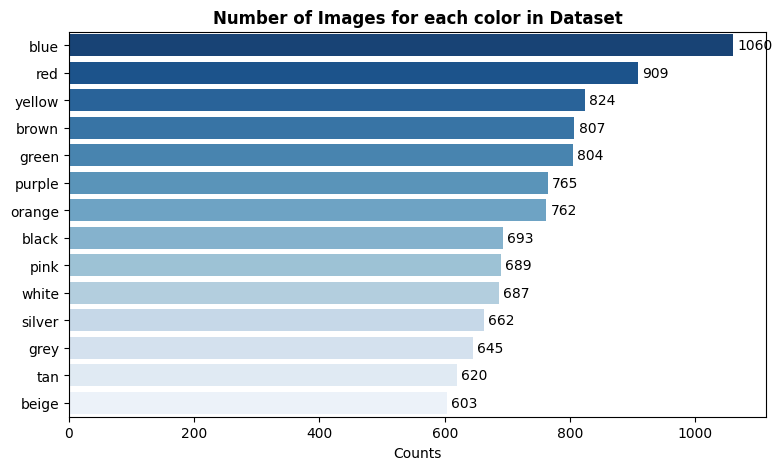

In [29]:
plt.figure(figsize=(9,5))
plt.title("Number of Images for each color in Dataset", fontdict={'weight':'bold'})
plt.xlabel('Counts')
ax = sns.barplot(y=list(sorted_class_counts.keys()), x=list(sorted_class_counts.values()), orient='h', palette='Blues_r')
for container in ax.containers:
    ax.bar_label(container, padding=3)
# Save figure
save_path = os.path.join(BASE_DIR, "artifacts/plots/class_distribution.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

In [30]:
# helper function to display specified amount of sample images from dataset
def display_random_images(images, colors,num_images=3):
    num_cols = 5
    num_rows = (num_images + num_cols - 1) // num_cols  
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(15, 5*num_rows))

    for i in range(num_images):
        row = i//num_cols
        col = i % num_cols
        # Select a random index
        random_index = random.randint(0, len(images) - 1)
        image = images[random_index]
        color = colors[random_index]

        # Load and display the image
        axs[row, col].imshow(image)
        axs[row, col].set_title(f'color: {color}')
        axs[row, col].axis('off')
        
    for i in range(num_images, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axs[row, col].axis('off')
        
    plt.tight_layout()
    plt.show()

In [31]:
images[0].shape

(128, 128, 3)

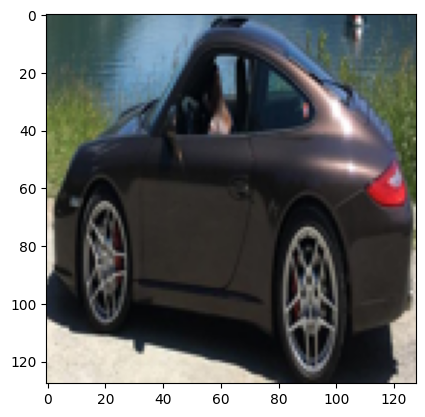

In [32]:
plt.imshow(images[3])

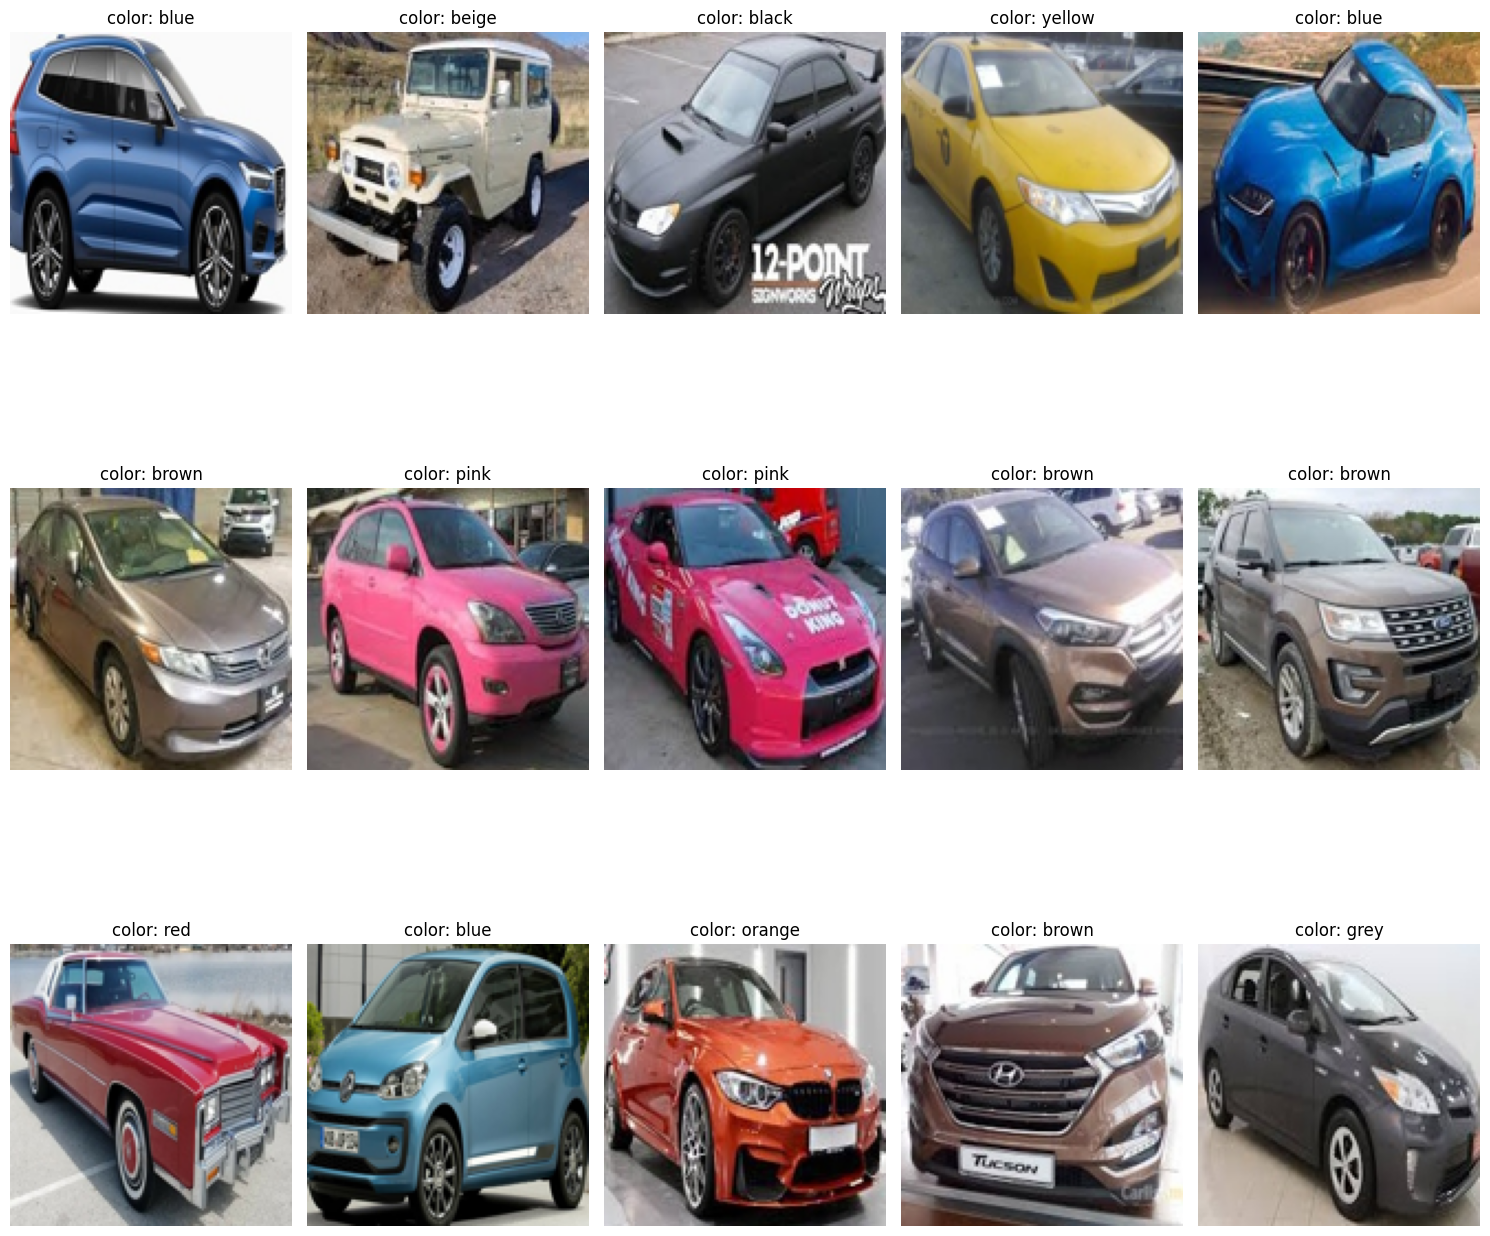

In [33]:
display_random_images(images,labels, 15)

### Data Augmentation

In [35]:
datagen = ImageDataGenerator(
    rotation_range=30,            
    width_shift_range=0.2,        
    height_shift_range=0.2,       
    horizontal_flip=True,     
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest'
)

# Convert images to NumPy arrays after augmentation
images_augmented = []
for image in images:
    augmented_image = datagen.random_transform(image)
    images_augmented.append(augmented_image)

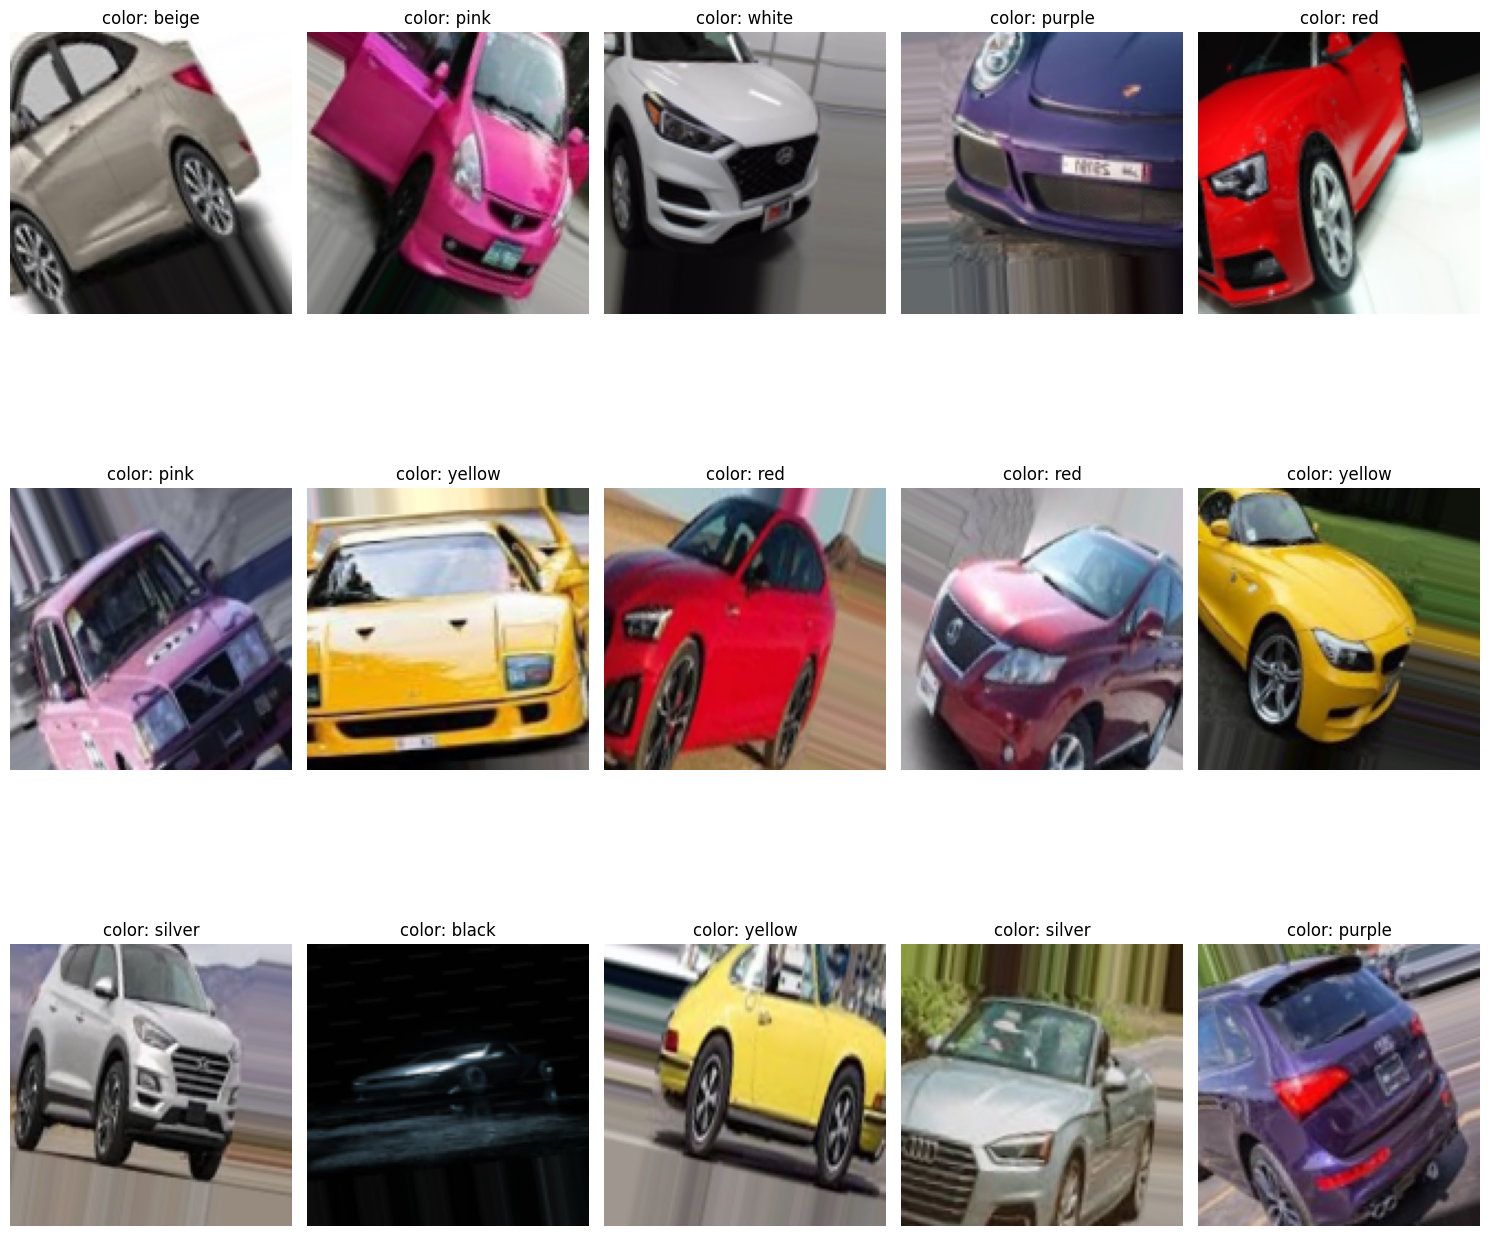

In [36]:
display_random_images(images_augmented,labels, 15)

### Label Encoding

In [37]:
label_encoder = LabelEncoder()

In [38]:
numerical_labels = label_encoder.fit_transform(labels)
numerical_labels

array([3, 3, 3, ..., 6, 6, 6])

In [39]:
len(numerical_labels)

10530

In [40]:
color_mappings = []
for label, numerical_label in zip(labels, numerical_labels):
    pair=(label,numerical_label)
    if pair not in color_mappings:
        color_mappings.append(pair)
color_mappings = sorted(color_mappings)
color_mappings

[('beige', 0),
 ('black', 1),
 ('blue', 2),
 ('brown', 3),
 ('green', 4),
 ('grey', 5),
 ('orange', 6),
 ('pink', 7),
 ('purple', 8),
 ('red', 9),
 ('silver', 10),
 ('tan', 11),
 ('white', 12),
 ('yellow', 13)]

In [41]:
images[0]

array([[[ 85,  57,  54],
        [ 82,  54,  53],
        [ 81,  53,  52],
        ...,
        [ 26,  26,  24],
        [ 26,  26,  24],
        [ 25,  25,  23]],

       [[ 86,  58,  55],
        [ 84,  56,  54],
        [ 82,  54,  53],
        ...,
        [ 26,  26,  24],
        [ 26,  26,  24],
        [ 25,  25,  23]],

       [[ 84,  54,  53],
        [ 83,  54,  56],
        [ 84,  55,  57],
        ...,
        [ 26,  26,  24],
        [ 26,  26,  24],
        [ 25,  25,  23]],

       ...,

       [[194, 195, 197],
        [194, 195, 197],
        [194, 195, 197],
        ...,
        [156, 155, 162],
        [146, 146, 155],
        [142, 145, 155]],

       [[194, 195, 197],
        [194, 195, 197],
        [194, 195, 197],
        ...,
        [157, 156, 163],
        [144, 144, 154],
        [143, 145, 157]],

       [[192, 193, 195],
        [192, 193, 195],
        [192, 193, 195],
        ...,
        [163, 162, 169],
        [142, 142, 152],
        [142, 144, 156]]

In [42]:
images_f = np.array(images)
labels_f = np.array(numerical_labels)

In [43]:
# Normalizing pixel values by dividing by 255 (tha max value)
images_f_2 = images_f/255
images_f_2[0]

array([[[0.33333333, 0.22352941, 0.21176471],
        [0.32156863, 0.21176471, 0.20784314],
        [0.31764706, 0.20784314, 0.20392157],
        ...,
        [0.10196078, 0.10196078, 0.09411765],
        [0.10196078, 0.10196078, 0.09411765],
        [0.09803922, 0.09803922, 0.09019608]],

       [[0.3372549 , 0.22745098, 0.21568627],
        [0.32941176, 0.21960784, 0.21176471],
        [0.32156863, 0.21176471, 0.20784314],
        ...,
        [0.10196078, 0.10196078, 0.09411765],
        [0.10196078, 0.10196078, 0.09411765],
        [0.09803922, 0.09803922, 0.09019608]],

       [[0.32941176, 0.21176471, 0.20784314],
        [0.3254902 , 0.21176471, 0.21960784],
        [0.32941176, 0.21568627, 0.22352941],
        ...,
        [0.10196078, 0.10196078, 0.09411765],
        [0.10196078, 0.10196078, 0.09411765],
        [0.09803922, 0.09803922, 0.09019608]],

       ...,

       [[0.76078431, 0.76470588, 0.77254902],
        [0.76078431, 0.76470588, 0.77254902],
        [0.76078431, 0

## Model Training

In [44]:
# Splitting data to get train, test and validation set
X_train, X_test, y_train, y_test = train_test_split(images_f_2, labels_f, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.75, random_state=3)

In [45]:
print(f"Training set size--> X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test set size--> X_test: {X_test.shape}, y_test: {y_test.shape}")
print(f"Validation set size--> X_val: {X_val.shape}, y_val: {y_val.shape}")

Training set size--> X_train: (7371, 128, 128, 3), y_train: (7371,)
Test set size--> X_test: (2370, 128, 128, 3), y_test: (2370,)
Validation set size--> X_val: (789, 128, 128, 3), y_val: (789,)


In [46]:
# Define the model
model = Sequential()

# Add layers
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001), input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(512, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.0001)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.7))
model.add(Dense(15, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.00002),
              loss='sparse_categorical_crossentropy',  
              metrics=['accuracy'])

# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,060,495 (15.49 MB)

 Trainable params: 4,060,495 (15.49 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(zip(np.unique(y_train), class_weights))

In [48]:
class_weights

array([1.22157773, 1.10377358, 0.70106525, 0.95901639, 0.93850267,
       1.15460526, 0.92530756, 1.12982833, 0.975     , 0.83571429,
       1.13469828, 1.23302108, 1.12021277, 0.90775862])

In [51]:
output_path = os.path.join(BASE_DIR, 'artifacts/models/Car_Color_Detection.keras')
checkpoint = ModelCheckpoint(output_path,monitor='val_loss',verbose=1,save_best_only=True,save_weights_only=False, mode="auto",save_freq='epoch')
Early_stop = EarlyStopping(patience=50,monitor='val_loss',restore_best_weights='True')
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=3, verbose=1, factor=0.5)
callback_list = [checkpoint,Early_stop, lr_scheduler]
BATCH_SIZE = 20
NUMBER_OF_EPOCHS = 100

In [52]:
history = model.fit(X_train, y_train, epochs=NUMBER_OF_EPOCHS, batch_size=BATCH_SIZE, validation_data=(X_val, y_val), callbacks=callback_list, class_weight=class_weight)

Epoch 1/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.3556 - loss: 2.0596
Epoch 1: val_loss improved from None to 1.49789, saving model to /Users/jayant/Documents/projects/car-color-detection/artifacts/models/Car_Color_Detection.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.3789 - loss: 1.9892 - val_accuracy: 0.6160 - val_loss: 1.4979 - learning_rate: 2.0000e-05
Epoch 2/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.4370 - loss: 1.8383
Epoch 2: val_loss improved from 1.49789 to 1.23800, saving model to /Users/jayant/Documents/projects/car-color-detection/artifacts/models/Car_Color_Detection.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 79s 213ms/step - accuracy: 0.4577 - loss: 1.7898 - val_accuracy: 0.6489 - val_loss: 1.2380 - learning_rate: 2.0000e-05
Epoch 3/100
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4918 - loss: 1.6777
Epoch 3: val_loss improved from 1.23800 to 1.16136, saving model to /Users/jayant/Documents/projects/car-color-d

In [53]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

In [55]:
with open(os.path.join(BASE_DIR,"artifacts/history/model_history.json"), "w") as f:
    json.dump(history.history, f)

## Model Evaluation

In [56]:
with open(os.path.join(BASE_DIR,"artifacts/history/model_history.json"), "r") as f:
    model_history = json.load(f)

In [57]:
model_history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

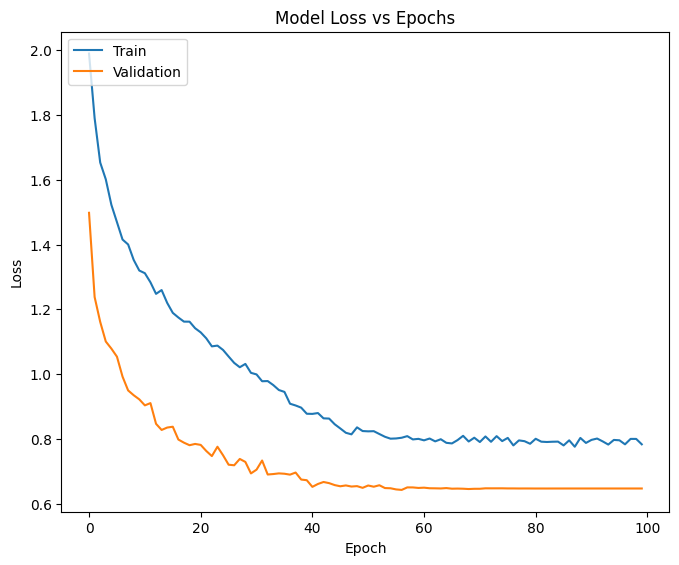

In [58]:
# Plotting Train and Validation Loss
plt.title('Model Loss vs Epochs')
plt.plot(model_history['loss'])
plt.plot(model_history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)

# Save Figure
save_path = os.path.join(BASE_DIR, "artifacts/plots/model_loss_vs_epochs.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

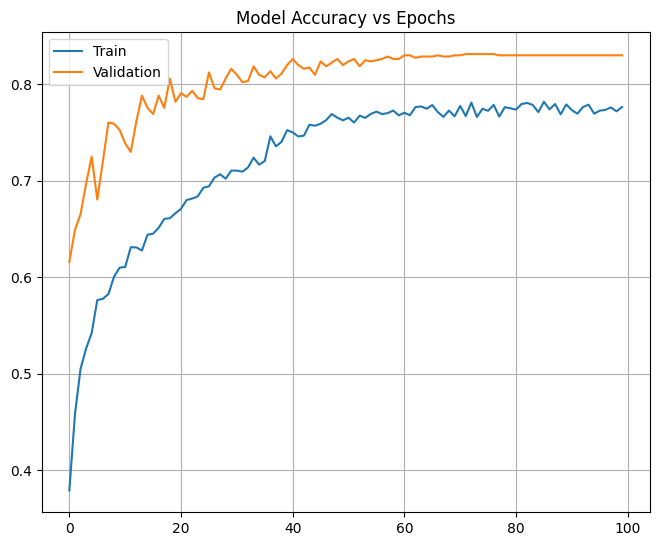

In [59]:
# Plotting Train and Validation Accuracy
plt.title('Model Accuracy vs Epochs')
plt.plot(model_history['accuracy'])
plt.plot(model_history['val_accuracy'])
plt.xlabel=('Epoch')
plt.ylabel=('Accuracy')
plt.legend(['Train','Validation'],loc='upper left')
plt.subplots_adjust(top=1.0,bottom=0.0,right=0.95,left=0,hspace=0.25,wspace=0.35)
plt.grid()

# Save Figure
save_path = os.path.join(BASE_DIR, "artifacts/plots/model_accuracy_vs_epochs.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

In [61]:
pred=model.predict(X_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step


In [62]:
i=0
Pred_l=[]
while(i<len(pred)):
    Pred_l.append(int(np.argmax(pred[i])))
    i=i+1

In [63]:
report=classification_report(y_test,Pred_l)
print(report)

              precision    recall  f1-score   support

           0       0.48      0.45      0.46       141
           1       0.84      0.85      0.85       164
           2       0.95      0.96      0.96       228
           3       0.81      0.80      0.81       197
           4       0.96      0.92      0.94       194
           5       0.64      0.59      0.62       128
           6       0.89      0.91      0.90       148
           7       0.92      0.92      0.92       162
           8       0.94      0.95      0.94       165
           9       0.95      0.93      0.94       210
          10       0.64      0.65      0.64       149
          11       0.46      0.51      0.48       142
          12       0.79      0.83      0.81       161
          13       0.95      0.95      0.95       181

    accuracy                           0.82      2370
   macro avg       0.80      0.80      0.80      2370
weighted avg       0.82      0.82      0.82      2370



In [65]:
report_dict = classification_report(y_test,Pred_l, output_dict=True)

with open(os.path.join(BASE_DIR,"artifacts/classification_report.json"), "w") as f:
    json.dump(report_dict, f, indent=4)

print("Classification report saved as JSON → classification_report.json")

Classification report saved as JSON → classification_report.json


In [66]:
print("Accuracy on test set: ", accuracy_score(y_test, Pred_l))

Accuracy on test set:  0.8210970464135021


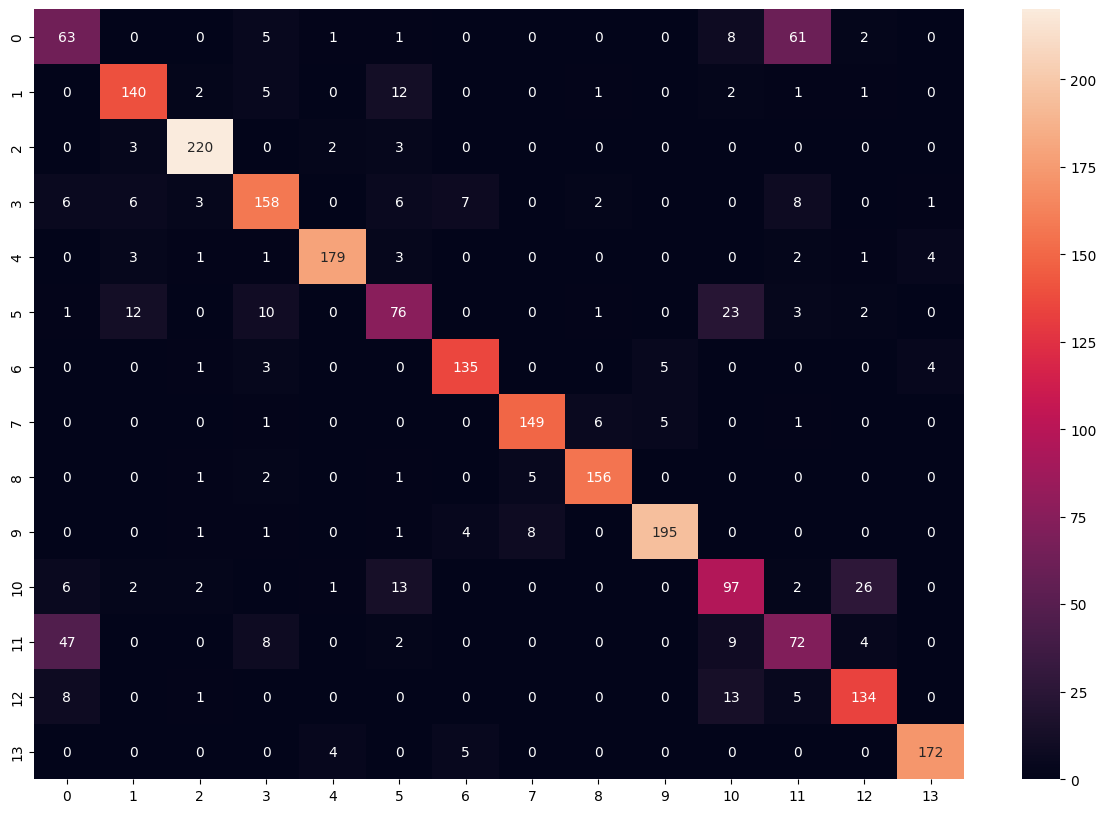

In [68]:
results=confusion_matrix(y_test,Pred_l)
plt.figure(figsize=(15,10))
sns.heatmap(results,annot=True, fmt=".0f")

# Save Figure
save_path = os.path.join(BASE_DIR, "artifacts/plots/confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')